# Day-Ahead Electricity Price Forecasting with Mamba Using Calendar Feature Stage

This notebook trains a Mamba model for day-ahead electricity price forecasting using a 1-week input window and the calendar feature stage, which includes date-based variables such as day of the week, month, holidays, and cyclic time encodings. The model is trained on data from 2023 and tested on 2024 data. Performance is evaluated using standard error metrics, and visualizations are generated to analyze forecast accuracy.

In [1]:
################################################################################
#  1) INSTALL AND IMPORTS
################################################################################
# !pip install --upgrade pip  # (Optional) upgrade pip
# !pip install mamba-ssm      # Install Mamba from PyPI

import requests
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error

################################################################################
#  2) READ CSV
################################################################################

train_df = pd.read_csv('~/data/training_data_small_with_calender_features.csv')
test_df = pd.read_csv('~/data/test_data_with_calender_features.csv')


train_df['ds'] = pd.to_datetime(train_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Check date ranges
print("First date in train_df:", train_df['ds'].min())
print("Last date in train_df:", train_df['ds'].max())
print("First date in test_df:", test_df['ds'].min())
print("Last date in test_df:", test_df['ds'].max())

# Define the exogenous variable lists
stat_exog_list = []  # Add any static variables if applicable
hist_exog_list = ['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
                  'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend']

futr_exog_list = hist_exog_list 

First date in train_df: 2022-12-31 23:00:00
Last date in train_df: 2024-01-01 22:00:00
First date in test_df: 2023-12-31 23:00:00
Last date in test_df: 2025-01-01 22:00:00


In [2]:
test_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
0,2023-12-31 23:00:00,0.10,electricity_prices,6,12,23,1,0,-2.449294e-16,1.000000,-0.781831,0.62349,-0.258819,0.965926
1,2024-01-01 00:00:00,0.01,electricity_prices,0,1,0,0,1,5.000000e-01,0.866025,0.000000,1.00000,0.000000,1.000000
2,2024-01-01 01:00:00,0.00,electricity_prices,0,1,1,0,1,5.000000e-01,0.866025,0.000000,1.00000,0.258819,0.965926
3,2024-01-01 02:00:00,-0.01,electricity_prices,0,1,2,0,1,5.000000e-01,0.866025,0.000000,1.00000,0.500000,0.866025
4,2024-01-01 03:00:00,-0.03,electricity_prices,0,1,3,0,1,5.000000e-01,0.866025,0.000000,1.00000,0.707107,0.707107


In [6]:


################################################################################
#  4) DEFINE THE MAMBA MODEL
################################################################################
from mamba_ssm import Mamba

class MambaForecaster(nn.Module):
    """
    - horizon (h): how many steps to forecast (24)
    - input_size: how many past time steps we feed in (e.g., 24*7)
    - exog_size: how many exogenous features per time step
    - d_model, d_state, etc.: Mamba hyperparameters
    """
    def __init__(
        self,
        horizon=24,
        input_size=168,        # e.g. 7 days if hourly 24*7
        exog_size=0,           # how many exogenous features
        d_model=32,
        d_state=16,
        d_conv=4,
        expand=2,
    ):
        super().__init__()
        self.horizon = horizon
        self.input_size = input_size
        self.exog_size = exog_size
        self.d_model   = d_model
        
        # We will embed (input_size + exog_size) "past features" into d_model dimension
        # For each time step in the past, we have 1 "y" + exog_size.
        # We'll keep it simple: flatten all past steps into a single vector:
        # shape = (batch_size, input_size*(1+exog_size)).
        # Then we linearly transform to d_model before feeding into Mamba.
        
        total_in_features = (input_size) + (input_size * exog_size)
        
        self.input_proj = nn.Linear(total_in_features, d_model)
        
        # A single Mamba block
        self.mamba_block = Mamba(
            d_model=d_model,
            d_state=d_state,
            d_conv=d_conv,
            expand=expand,
        )
        
        # Output: from Mamba hidden dimension -> horizon
        self.out_proj = nn.Linear(d_model, horizon)
        
    def forward(self, past_y, past_exog):
        """
        Inputs:
          past_y:    shape (batch_size, input_size)
          past_exog: shape (batch_size, input_size, exog_size)
          
        Returns:
          forecast: shape (batch_size, horizon)
        """
        batch_size = past_y.shape[0]
        
        # Flatten exogenous: (batch_size, input_size, exog_size) -> (batch_size, input_size*exog_size)
        past_exog_flat = past_exog.reshape(batch_size, -1)
        
        # Combine main series + exog into one vector
        # shape = (batch_size, input_size + input_size*exog_size)
        combined_input = torch.cat([past_y, past_exog_flat], dim=1)
        
        # Project to d_model
        x = self.input_proj(combined_input)  # (batch_size, d_model)
        
        # We want to interpret dimension 1 as "sequence length" for Mamba
        # But here we have only shape (batch_size, d_model). 
        # So let's treat it as if seq_len=1, dim=d_model.
        x = x.unsqueeze(1)  # (batch_size, 1, d_model)
        
        # Pass through Mamba (it expects shape (B, L, d_model)), returns same shape
        hidden = self.mamba_block(x)  # (batch_size, 1, d_model)
        
        # We only have L=1 in this design, so we take hidden[:, -1, :] if we had a longer L
        hidden = hidden[:, 0, :]  # (batch_size, d_model)
        
        # Finally project to horizon
        forecast = self.out_proj(hidden)  # (batch_size, horizon)
        
        return forecast


In [7]:

################################################################################
#  5) PREPARE TENSORS AND DATALOADERS
################################################################################

# We'll define the exogenous variables
hist_exog_list = [
    'month_sin','month_cos','day_of_week_sin','day_of_week_cos',
    'hour_sin','hour_cos','is_holiday','is_weekend'
]

# For a day-ahead approach:
#  - horizon = 24
#  - input_size = 24*7 (7 days)
HORIZON = 24
INPUT_SIZE = 24*7

# We will create a function that, given a DataFrame with 'y' and exogs,
# returns rolling samples: each sample is (past_y, past_exog) -> next 24 hours of y
# For simplicity, we won't do fancy train/val splits, just produce raw pairs.

def make_dataset(df, input_size=INPUT_SIZE, horizon=HORIZON, exog_cols=None):
    """
    Creates (X,y) pairs from a time-based DataFrame. We assume df is chronological.
    exog_cols: list of columns to use as exogenous features.
    
    Returns lists of:
      past_y_list: shape (num_samples, input_size)
      past_exog_list: shape (num_samples, input_size, len(exog_cols))
      future_y_list: shape (num_samples, horizon)  # for training
      future_time_stamps: the ds times for the forecast horizon
    """
    if exog_cols is None:
        exog_cols = []
    
    arr_y = df['y'].values
    arr_exog = df[exog_cols].values if exog_cols else None
    
    timestamps = df['ds'].values
    
    samples = []
    
    # We can only form a sample if we have at least input_size past points
    # plus horizon future points. We'll do a rolling approach.
    for i in range(len(df) - input_size - horizon):
        past_y    = arr_y[i : i+input_size]
        future_y  = arr_y[i+input_size : i+input_size+horizon]
        
        if arr_exog is not None:
            past_exog = arr_exog[i : i+input_size, :]
        else:
            past_exog = np.zeros((input_size, 0))
        
        # We'll store the future timestamps, too, if we want them for analysis
        future_ts = timestamps[i+input_size : i+input_size+horizon]
        
        samples.append((past_y, past_exog, future_y, future_ts))
    
    return samples

# Prepare training dataset from train_df
train_data = train_df.sort_values('ds').reset_index(drop=True)
train_samples = make_dataset(
    train_data,
    input_size=INPUT_SIZE,
    horizon=HORIZON,
    exog_cols=hist_exog_list
)

# Convert them to PyTorch Tensors
X_past_y      = []
X_past_exog   = []
Y_future      = []

for (past_y, past_exog, future_y, _) in train_samples:
    X_past_y.append(past_y)
    X_past_exog.append(past_exog)
    Y_future.append(future_y)

X_past_y      = torch.tensor(X_past_y,      dtype=torch.float32)
X_past_exog   = torch.tensor(X_past_exog,   dtype=torch.float32)
Y_future      = torch.tensor(Y_future,      dtype=torch.float32)

# We'll store them in a simple TensorDataset
train_dataset = torch.utils.data.TensorDataset(X_past_y, X_past_exog, Y_future)
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

################################################################################
#  6) INSTANTIATE AND TRAIN THE MAMBA MODEL
################################################################################

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

model = MambaForecaster(
    horizon=HORIZON,
    input_size=INPUT_SIZE,
    exog_size=len(hist_exog_list),
    d_model=32,
    d_state=16,
    d_conv=4,
    expand=2,
).to(device)

criterion = nn.L1Loss()  # MAE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

max_epochs = 100  # increase as needed
model.train()

for epoch in range(1, max_epochs+1):
    total_loss = 0.0
    for batch in train_loader:
        past_y, past_exog, y_true = batch
        past_y     = past_y.to(device)
        past_exog  = past_exog.to(device)
        y_true     = y_true.to(device)
        
        optimizer.zero_grad()
        y_pred = model(past_y, past_exog)  # shape (batch_size, horizon)
        
        loss = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * past_y.size(0)
    
    epoch_loss = total_loss / len(train_loader.dataset)
    if epoch % 1 == 0:
        print(f"Epoch {epoch}/{max_epochs}, MAE loss: {epoch_loss:.4f}")


Using device: cuda
Epoch 1/10, MAE loss: 33.8398
Epoch 2/10, MAE loss: 23.7182
Epoch 3/10, MAE loss: 21.4143
Epoch 4/10, MAE loss: 20.6182
Epoch 5/10, MAE loss: 19.9877
Epoch 6/10, MAE loss: 19.5707
Epoch 7/10, MAE loss: 19.2371
Epoch 8/10, MAE loss: 18.7932
Epoch 9/10, MAE loss: 18.1495
Epoch 10/10, MAE loss: 18.3417


In [8]:

################################################################################
#  7) DAY-BY-DAY PREDICTION ON TEST SET
################################################################################
# We replicate DAEPF approach, generating day-by-day forecasts and collecting them.

test_data = test_df.sort_values('ds').reset_index(drop=True)

# For day-by-day prediction, we do:
#  - For each day in the test range, we take the preceding 'input_size' hours from test_data
#    (which simulates we have real data up to that point),
#  - Then we do a single forward pass and predict the next 24 hours.
#
# We'll store the predictions in a DataFrame with columns ['ds', 'y_pred', 'y_actual'].

model.eval()

test_predictions = []
time_stamps = test_data['ds'].values

# We'll step through test_data in daily increments
# But we must ensure we have enough "history" = input_size hours
# We'll define a date range that leaves room for those input_size hours plus horizon
start_ts = test_data['ds'].min()
end_ts   = test_data['ds'].max()

# Because the test set might overlap with the training set, you can do an approach
# that uses the last part of train data if needed. For simplicity, we'll only use test_data.
dates_for_forecast = pd.date_range(start=start_ts, end=end_ts - pd.Timedelta(hours=INPUT_SIZE+HORIZON), freq='24H')

for current_day in dates_for_forecast:
    
    window_start = current_day
    window_end   = current_day + pd.Timedelta(hours=INPUT_SIZE-1)
    forecast_start = current_day + pd.Timedelta(hours=INPUT_SIZE)
    forecast_end   = current_day + pd.Timedelta(hours=INPUT_SIZE + HORIZON - 1)
    
    # Filter test_data for the "history" portion
    hist_mask = (test_data['ds'] >= window_start) & (test_data['ds'] <= window_end)
    hist_slice = test_data[hist_mask].copy()
    
    # We only proceed if we have exactly 'INPUT_SIZE' hours
    if len(hist_slice) != INPUT_SIZE:
        continue
    
    # Filter test_data for the "future" portion
    futr_mask = (test_data['ds'] >= forecast_start) & (test_data['ds'] <= forecast_end)
    futr_slice = test_data[futr_mask].copy()
    
    if len(futr_slice) != HORIZON:
        # If we don't have exactly 24 hours, skip
        continue
    
    # Prepare model inputs
    past_y    = torch.tensor(hist_slice['y'].values, dtype=torch.float32).unsqueeze(0).to(device)
    past_exog = torch.tensor(hist_slice[hist_exog_list].values, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Forward pass
    with torch.no_grad():
        y_pred = model(past_y, past_exog).cpu().numpy().flatten()  # shape (24,)
    
    # Store predictions
    for i in range(HORIZON):
        test_predictions.append({
            'ds': futr_slice.iloc[i]['ds'],
            'y_pred': y_pred[i],
            'y_actual': futr_slice.iloc[i]['y']
        })

forecast_df = pd.DataFrame(test_predictions).sort_values('ds').reset_index(drop=True)



In [9]:

################################################################################
#  8) METRICS
################################################################################
mae  = mean_absolute_error(forecast_df['y_actual'], forecast_df['y_pred'])
mse  = mean_squared_error(forecast_df['y_actual'], forecast_df['y_pred'])
rmse = np.sqrt(mse)

print("Model Performance (Mamba):")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# Day-of-week breakdown
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
forecast_df['day_of_week'] = forecast_df['ds'].dt.dayofweek

metrics_by_day = {}
for day in range(7):
    day_data = forecast_df[forecast_df['day_of_week'] == day]
    if len(day_data) == 0:
        continue
    mae_day  = mean_absolute_error(day_data['y_actual'], day_data['y_pred'])
    mse_day  = mean_squared_error(day_data['y_actual'], day_data['y_pred'])
    rmse_day = np.sqrt(mse_day)
    metrics_by_day[day] = {'MAE': mae_day, 'MSE': mse_day, 'RMSE': rmse_day}

metrics_df = pd.DataFrame(metrics_by_day).T
print("\nMetrics by Day of the Week:")
print(metrics_df)

Model Performance (Mamba):
MAE:  22.72
MSE:  1545.17
RMSE: 39.31

Metrics by Day of the Week:
         MAE          MSE       RMSE
0  20.742132   891.498714  29.857976
1  21.943457  1385.169883  37.217870
2  24.839753  2444.371966  49.440590
3  26.140539  2864.934108  53.525079
4  19.785249   810.301498  28.465795
5  24.342548  1250.323925  35.359920
6  21.329292  1185.711690  34.434165


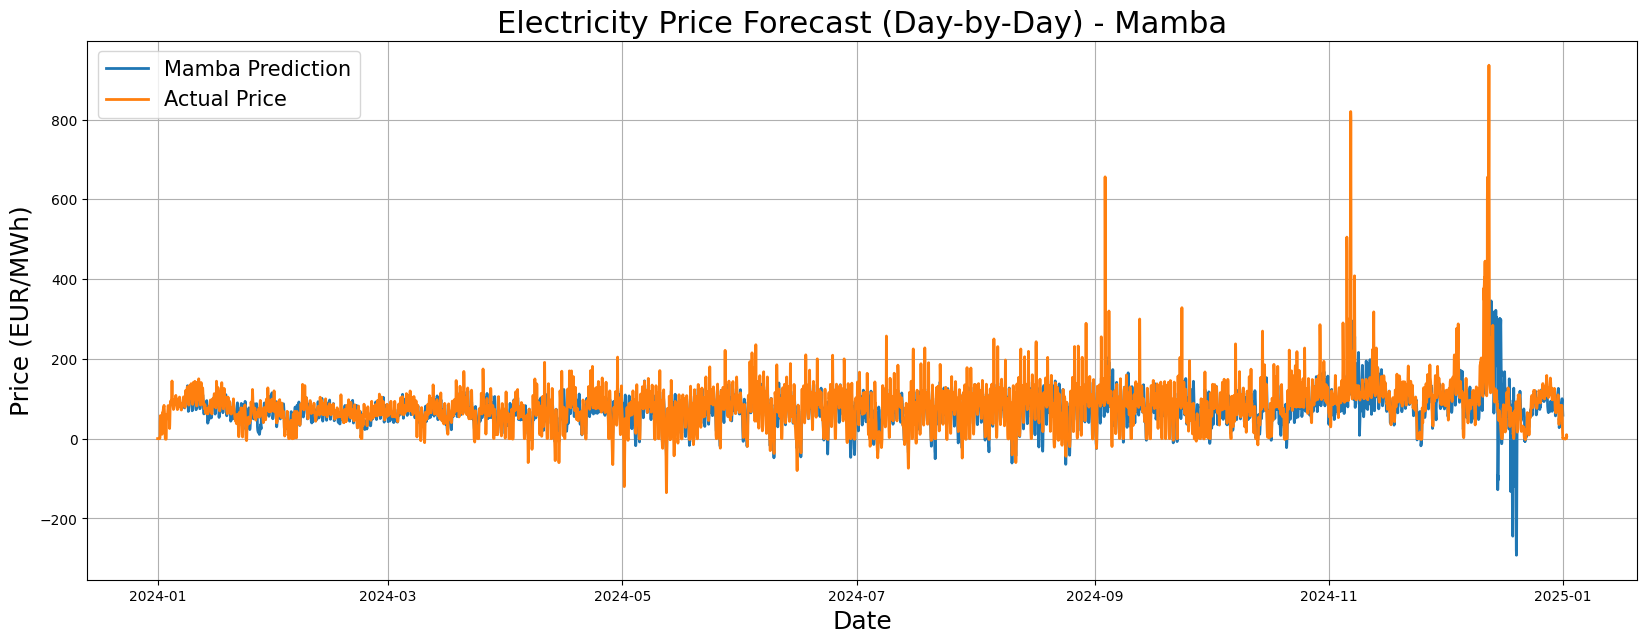

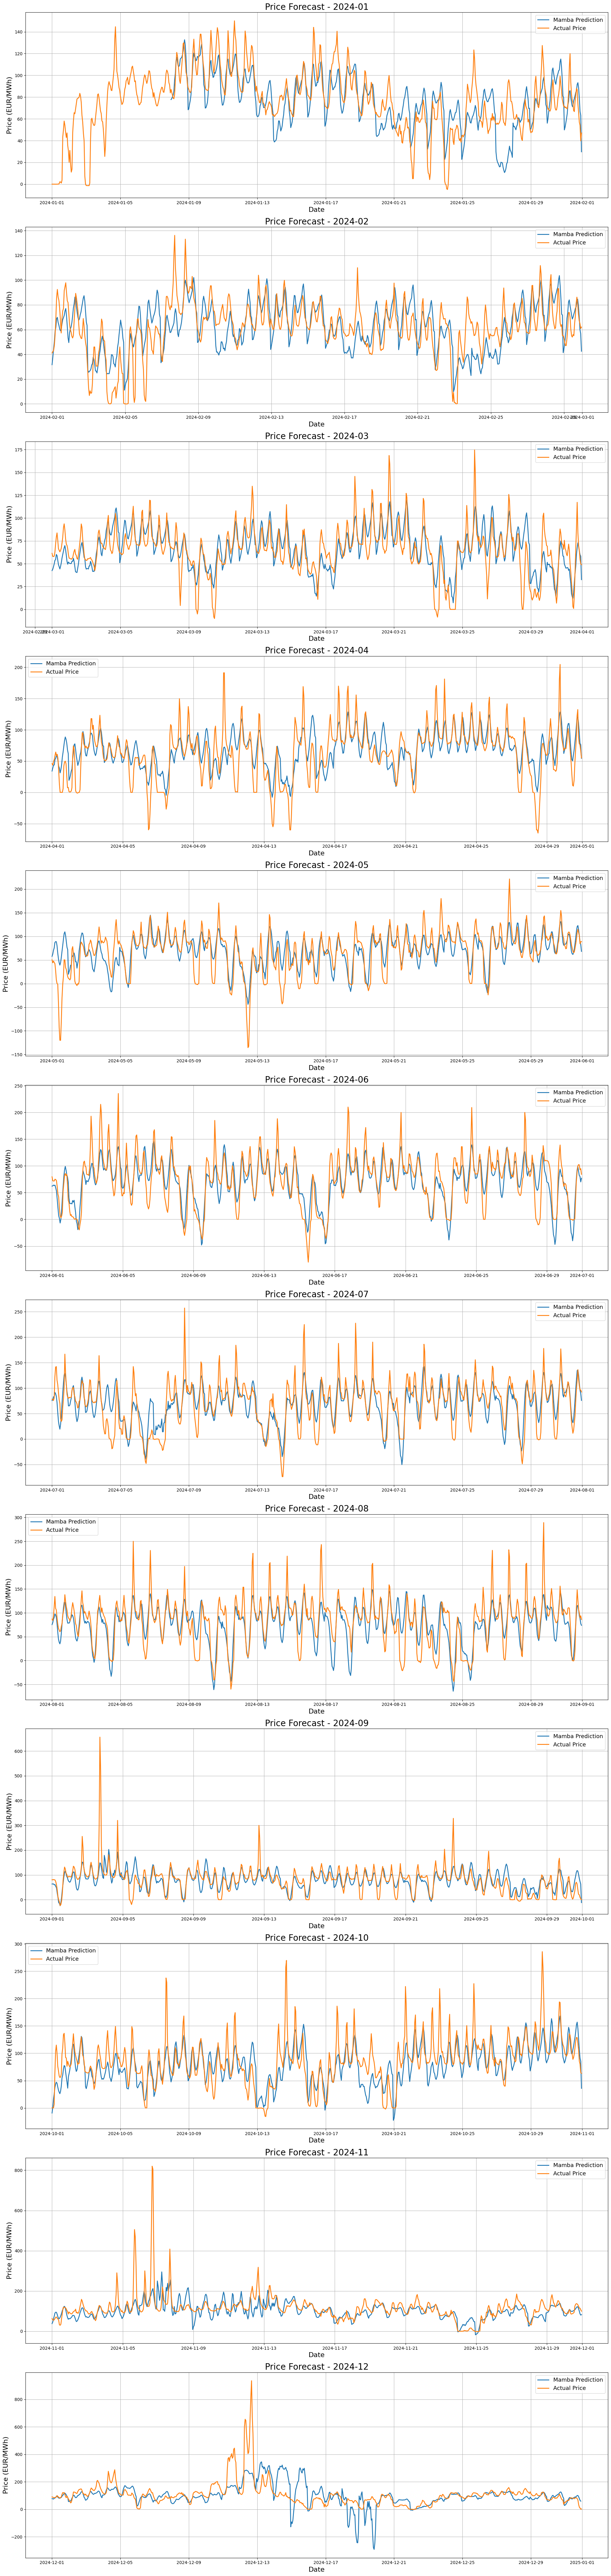

,ds,y_pred,y_actual,day_of_week,month_period
0,2024-01-07 23:00:00,77.764420,87.02,6,2024-01
1,2024-01-08 00:00:00,78.586319,84.32,0,2024-01
2,2024-01-08 01:00:00,80.365585,81.82,0,2024-01
3,2024-01-08 02:00:00,81.823540,79.11,0,2024-01
4,2024-01-08 03:00:00,85.412025,78.48,0,2024-01
5,2024-01-08 04:00:00,95.911270,82.10,0,2024-01
6,2024-01-08 05:00:00,101.538963,94.30,0,2024-01
7,2024-01-08 06:00:00,113.023773,111.10,0,2024-01
8,2024-01-08 07:00:00,116.685730,121.11,0,2024-01
9,2024-01-08 08:00:00,112.622864,117.83,0,2024-01


In [10]:

################################################################################
#  9) PLOTS
################################################################################

# 9.1: Single overall forecast
fig, ax = plt.subplots(figsize=(20, 7))
ax.plot(forecast_df['ds'], forecast_df['y_pred'], label='Mamba Prediction', linewidth=2)
# Plot actual
test_plot_df = test_data[['ds','y']].copy()
test_plot_df = test_plot_df.set_index('ds')
ax.plot(test_plot_df.index, test_plot_df['y'], label='Actual Price', linewidth=2)

ax.set_title('Electricity Price Forecast (Day-by-Day) - Mamba', fontsize=22)
ax.set_ylabel('Price (EUR/MWh)', fontsize=18)
ax.set_xlabel('Date', fontsize=18)
ax.legend(prop={'size': 15})
ax.grid()
plt.show()

# 9.2: Plot each month separately
forecast_df['month_period'] = forecast_df['ds'].dt.to_period('M')
unique_months = forecast_df['month_period'].unique()

fig, axes = plt.subplots(len(unique_months), 1, figsize=(20, 7*len(unique_months)))
if len(unique_months) == 1:
    axes = [axes]  # force array

for i, month_val in enumerate(unique_months):
    ax = axes[i]
    sub_pred = forecast_df[forecast_df['month_period'] == month_val]
    sub_test = test_plot_df[test_plot_df.index.to_period('M') == month_val]
    
    ax.plot(sub_pred['ds'], sub_pred['y_pred'], label='Mamba Prediction', linewidth=2)
    ax.plot(sub_test.index, sub_test['y'], label='Actual Price', linewidth=2)
    ax.set_title(f'Price Forecast - {month_val}', fontsize=20)
    ax.set_ylabel('Price (EUR/MWh)', fontsize=16)
    ax.set_xlabel('Date', fontsize=16)
    ax.legend(prop={'size': 13})
    ax.grid()

plt.tight_layout()
plt.show()

# Display a small preview of the final forecast DataFrame
forecast_df.head(10)